In [1]:
using Pkg
Pkg.activate(normpath(@__DIR__,  ".."))

  Activating project at `~/DART`


In [2]:
using JLD2, PyPlot, Statistics, StatsBase
Line2D = PyPlot.matplotlib.lines.Line2D;

In [ ]:
utils_dir = normpath(joinpath(@__DIR__, "..", "utils"))

include(joinpath(utils_dir, "reactions.jl"))
include(joinpath(utils_dir, "ssa.jl"))
include(joinpath(utils_dir, "utils.jl"))

mkpath("figs");  # create a folder to save figs

#### load data

In [4]:
project_root = dirname(Pkg.project().path);   # .../DART

In [5]:
# Reusable base folder
data_dir = "synthetic_data/ideal_data_res"

"""
    load_group(dir, on_file, off_file, acc_file)

Load three JLD2 files for a group:
- `on_file`  -> extract ON means (index 1)
- `off_file` -> extract OFF means (index 2)
- `acc_file` -> extract accuracies and keep records

Returns a named tuple: (onx, ony, offx, offy, acc, records)
"""
function load_group(dir, on_file, off_file, acc_file)
    # ON
    @load joinpath(project_root, data_dir, on_file) rn_met_dl
    onx = [m.truet_mean[1] for m in rn_met_dl]
    ony = [m.binart_mean[1] for m in rn_met_dl]

    # OFF
    @load joinpath(project_root, data_dir, off_file) rn_met_dl
    #@load joinpath(dir, off_file) rn_met_dl
    offx = [m.truet_mean[2] for m in rn_met_dl]
    offy = [m.binart_mean[2] for m in rn_met_dl]

    # ACC + keep records
    @load joinpath(project_root, data_dir, acc_file) rn_met_dl
    #@load joinpath(dir, acc_file) rn_met_dl
    acc     = [m.acc for m in rn_met_dl]
    records = copy(rn_met_dl)

    return (onx=onx, ony=ony, offx=offx, offy=offy, acc=acc, records=records)
end

# ---- Define file triplets per group ----
b   = load_group(data_dir,
        "mgen_dlb33_compare_seed_60.jld2",
        "mgen_dlb33_compare_seed_18.jld2",
        "mgen_dlb33_compare_seed_58.jld2");

nb1 = load_group(data_dir,
        "mgen_dlnb133_compare_seed_12.jld2",
        "mgen_dlnb133_compare_seed_18.jld2",
        "mgen_dlnb133_compare_seed_11.jld2")

nb0 = load_group(data_dir,
        "mgen_dlnb033_compare_seed_73.jld2",
        "mgen_dlnb033_compare_seed_14.jld2",
        "mgen_dlnb033_compare_seed_49.jld2")


# ---- Concatenate results ----
onx_scatter  = vcat(b.onx,  nb1.onx,  nb0.onx)
ony_scatter  = vcat(b.ony,  nb1.ony,  nb0.ony)
offx_scatter = vcat(b.offx, nb1.offx, nb0.offx)
offy_scatter = vcat(b.offy, nb1.offy, nb0.offy)
rn_acc_dl    = vcat(b.acc,  nb1.acc,  nb0.acc)

# If you also want a combined rn_met_dl:
rn_met_dl = vcat(b.records, nb1.records, nb0.records);

In [6]:
# Base folder
project_root = dirname(Pkg.project().path);   # .../DART

data_dir = "synthetic_data/base_compare"

"""
    load_compare(path)

Load one compare-method file from JLD2.
Returns a tuple (filter, met).
"""
function load_compare(path::String)
    data = JLD2.load(path)
    return data["rn_binar_filter"], data["rn_met_binar"]
end

# ---- Load all groups ----
hmmb_filter,  hmmb_met  = load_compare(joinpath(project_root,data_dir, "genb_hmm.jld2"))
mab_filter,   mab_met   = load_compare(joinpath(project_root,data_dir, "genb_ma.jld2"))
sgb_filter,   sgb_met   = load_compare(joinpath(project_root, data_dir, "genb_sg.jld2"))

#hmmb_filter,  hmmb_met  = load_compare(joinpath(data_dir, "genb_hmm.jld2"))
mab_filter,   mab_met   = load_compare(joinpath(project_root,data_dir, "genb_ma.jld2"))
sgb_filter,   sgb_met   = load_compare(joinpath(project_root,data_dir, "genb_sg.jld2"))

hmmnb1_filter, hmmnb1_met = load_compare(joinpath(project_root,data_dir, "gennb1_hmm.jld2"))
manb1_filter,  manb1_met  = load_compare(joinpath(project_root,data_dir, "gennb1_ma.jld2"))
sgnb1_filter,  sgnb1_met  = load_compare(joinpath(project_root,data_dir, "gennb1_sg.jld2"))

hmmnb0_filter, hmmnb0_met = load_compare(joinpath(project_root,data_dir, "gennb0_hmm.jld2"))
manb0_filter,  manb0_met  = load_compare(joinpath(project_root,data_dir, "gennb0_ma.jld2"))
sgnb0_filter,  sgnb0_met  = load_compare(joinpath(project_root,data_dir, "gennb0_sg.jld2"))

# ---- Concatenate results ----
rn_hmm_filter = vcat(hmmb_filter, hmmnb1_filter, hmmnb0_filter)
rn_ma_filter  = vcat(mab_filter,  manb1_filter,  manb0_filter)
rn_sg_filter  = vcat(sgb_filter,  sgnb1_filter,  sgnb0_filter)

rn_met_hmm = vcat(hmmb_met, hmmnb1_met, hmmnb0_met)
rn_met_ma  = vcat(mab_met,  manb1_met,  manb0_met)
rn_met_sg  = vcat(sgb_met,  sgnb1_met,  sgnb0_met);

In [7]:
# ---------- paths ----------
project_root = dirname(Pkg.project().path)           # .../DART
data_dir     = joinpath(project_root, "synthetic_data/base_compare")

# ---------- loader ----------
load_compare(path::AbstractString) = begin
    d = JLD2.load(path)
    d["rn_binar_filter"], d["rn_met_binar"]
end

# ---------- config ----------
groups  = ["genb", "gennb1", "gennb0"]
methods = ["hmm", "ma", "sg"]

# results[(group, method)] = (filter, met)
results = Dict{Tuple{String,String}, Tuple{Any,Any}}()

for g in groups, m in methods
    results[(g, m)] = load_compare(joinpath(data_dir, "$(g)_$(m).jld2"))
end

# ---------- concatenate ----------
rn_filter = Dict(m => vcat((results[(g, m)][1] for g in groups)...) for m in methods)
rn_met    = Dict(m => vcat((results[(g, m)][2] for g in groups)...) for m in methods)

rn_hmm_filter = rn_filter["hmm"];   rn_met_hmm = rn_met["hmm"]
rn_ma_filter  = rn_filter["ma"];    rn_met_ma  = rn_met["ma"]
rn_sg_filter  = rn_filter["sg"];    rn_met_sg  = rn_met["sg"];

#### plot

In [8]:
fs1 = 11.5; fs2 = 10.5; fs3 = 10; wd = 1.2

function style_ax!(ax; labelsize=fs2)
    ax.tick_params(axis="both", labelsize=labelsize, width=wd)
    for spine in ax.spines.values(); spine.set_linewidth(wd); end
end

function split_by_ratio(rn_met, thresh)
    ratio = [m.p[end-1] / m.truet_mean[2] for m in rn_met]
    idl = findall(>(thresh), ratio)
    ids = findall(<=(thresh), ratio)
    return ids, idl
end

function plot_scatter(ax, x, y, ylabel, rn_met, thresh; second_leg=false)
    ids, idl = split_by_ratio(rn_met, thresh)
    accs = [m.acc for m in rn_met]
    maccs = round(mean(accs[ids]), digits=3)
    maccl = round(mean(accs[idl]), digits=3)

    sc1 = ax.scatter(x[idl], y[idl], s=10, c="#abd9e9",
        label=L"\langle \alpha \rangle_{\Lambda > 0.5} = " * string(maccl))
    sc2 = ax.scatter(x[ids], y[ids], s=10, facecolors="none", edgecolors="#fdae61",
        linewidths=1.0, label=L"\langle \alpha \rangle_{\Lambda \leq 0.5} = " * string(maccs))

    sc1.set_rasterized(true)
    sc2.set_rasterized(true)

    xy_min, xy_max = minimum(vcat(x, y)) * 0.5, maximum(vcat(x, y)) * 1.5
    ax.plot(xy_min:0.1:xy_max, xy_min:0.1:xy_max, c="#2c7bb6", linestyle="--", linewidth=1.5)
    ax.set_xlim(xy_min, xy_max); ax.set_ylim(xy_min, xy_max)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylabel(ylabel, fontsize=fs1)
    style_ax!(ax)

    leg1 = ax.legend(scatterpoints=1, borderpad=0.2, fontsize=fs3, loc="lower right")
    ax.add_artist(leg1)

    if second_leg
        handles = [
            Line2D([], [], marker="o", color="w", markerfacecolor="#abd9e9", markersize=6,
                label=L"\Lambda > " * string(thresh)),
            Line2D([], [], marker="o", color="w", markeredgecolor="#fdae61",
                markerfacecolor="none", markersize=6, label=L"\Lambda \leq " * string(thresh))
        ]
        ax.legend(handles=handles, loc="upper left", fontsize=fs3)
    end
end

function plot_hist(ax, rn_met, rn_mets, thresh)
    ids, idl = split_by_ratio(rn_met, thresh)
    accs = [m.acc for m in rn_met]

    for (idx, color, edge, lw, label, style) in [
        (idl, "#abd9e9", "white",  0.3, L"\Lambda > "  * string(thresh), (;)),
        (ids, "none",    "#fdae61", 1.2, L"\Lambda \leq " * string(thresh), (;))
    ]
        counts, bins, _ = plt.hist(accs[idx], bins=FD_bins(accs[idx]), alpha=0)
        ncounts = counts ./ sum(counts)
        ax.bar(bins[1:end-1], ncounts, width=diff(bins),
            facecolor=color, edgecolor=edge, lw=lw, label=label)
    end

    ax.set_ylabel("Probability", fontsize=fs1)
    ax.legend(scatterpoints=1, borderpad=0.2, fontsize=fs3, loc="upper left")
    ax.set_yticks(0:0.05:maximum(ax.get_ylim()))
    min_acc = minimum(m.acc for m in vcat(rn_mets...))
    ax.set_xlim(min_acc - 0.1, 1.0)
    style_ax!(ax; labelsize=10)
end

function plot_comparison(rn_mets, titles, thresh; bold_labels=String[], ylim_overrides=Dict(), ypos=nothing)
    nrows = length(rn_mets)
    fig, axs = plt.subplots(nrows, 3, figsize=(10.8, 2.75 * nrows))

    for (i, rn_met) in enumerate(rn_mets)
        plot_hist(axs[i,1], rn_met, rn_mets, thresh)

        onx  = [m.truet_mean[1] for m in rn_met]
        ony  = [m.binart_mean[1] for m in rn_met]
        plot_scatter(axs[i,2], onx, ony, "Mean on-time", rn_met, thresh)

        offx = [m.truet_mean[2] for m in rn_met]
        offy = [m.binart_mean[2] for m in rn_met]
        plot_scatter(axs[i,3], offx, offy, "Mean off-time", rn_met, thresh)

        # Apply any per-row ylim overrides: e.g. Dict((2,3) => [0.02, 11])
        for ((ri, ci), lim) in ylim_overrides
            ri == i && axs[ri, ci].set_ylim(lim)
        end
    end

    # Bottom row x-labels
    axs[end,1].set_xlabel(L"\mathrm{Accuracy}~\alpha", fontsize=fs1)
    axs[end,2].set_xlabel("True mean on-time", fontsize=fs1)
    axs[end,3].set_xlabel("True mean off-time", fontsize=fs1)

    # Row labels
    for (i, label) in enumerate(titles)
        fw = label in bold_labels ? "semibold" : "normal"
        fig.text(0.005, ypos[i], label, fontsize=12.5, va="center", ha="right",
                 fontweight=fw, rotation=90)
    end

    fig.tight_layout()
    return fig
end;

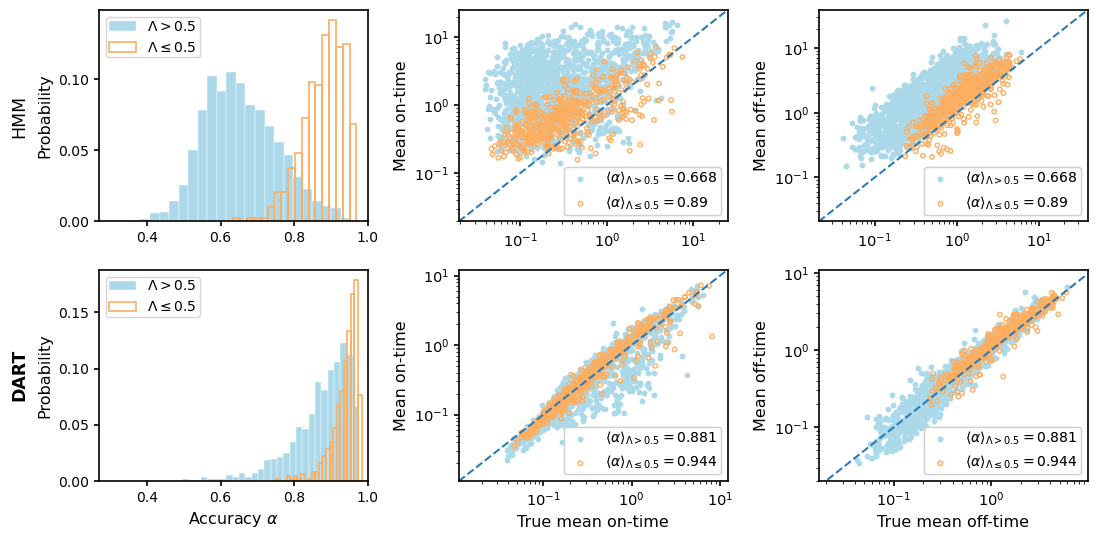

In [10]:
# Case 1: HMM + DART
fig1 = plot_comparison(
    [rn_met_hmm, rn_met_dl], ["HMM", "DART"], 0.5;
    bold_labels=["DART"],
    ylim_overrides=Dict((2,3) => [0.02, 11]), ypos=[0.78, 0.31])

fig1.savefig("figs/compare_all2.pdf", bbox_inches="tight", dpi=800);

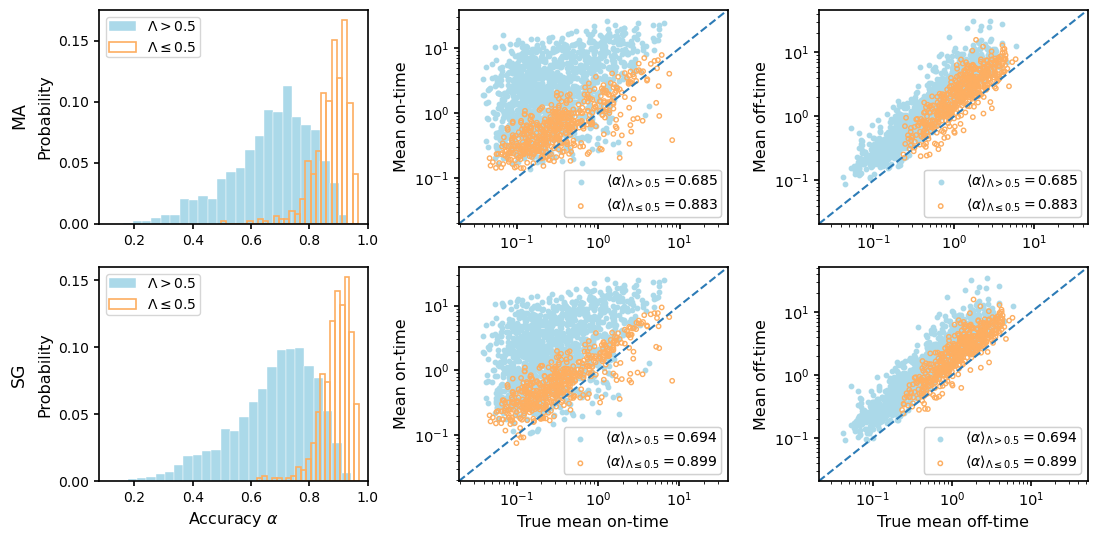

In [11]:
# Case 2: MA vs SG
fig2 = plot_comparison(
    [rn_met_ma, rn_met_sg], ["MA", "SG"], 0.5; ypos=[0.78, 0.31])

fig2.savefig("figs/compare_masg.pdf", bbox_inches="tight", dpi=800);

#### R^2 calculations

In [12]:
#### correlation calculations
hmm_trues = [m.truet_mean for m in rn_met_hmm]
hmm_vals = [m.binart_mean for m in rn_met_hmm];

ma_trues = [m.truet_mean for m in rn_met_ma]
ma_vals = [m.binart_mean for m in rn_met_ma];

sg_trues = [m.truet_mean for m in rn_met_sg]
sg_vals = [m.binart_mean for m in rn_met_sg];

In [7]:
fit_line(map(x->x[1],hmm_trues),map(x->x[1],hmm_vals)),fit_line(map(x->x[2],hmm_trues),map(x->x[2],hmm_vals))

((1.3146241926339253, 1.6360000759963016, 0.16652946439366922), (1.5469434272070897, 1.0637340689239052, 0.34514613300482744))

In [8]:
fit_line(map(x->x[1],ma_trues),map(x->x[1],ma_vals)),fit_line(map(x->x[2],ma_trues),map(x->x[2],ma_vals))

((1.9018210607624542, 1.9767524199692303, 0.16441982042349346), (2.3108955456660643, 0.4278353045325254, 0.4829903357345223))

In [9]:
fit_line(map(x->x[1],sg_trues),map(x->x[1],sg_vals)),fit_line(map(x->x[2],sg_trues),map(x->x[2],sg_vals))

((2.0618264498803125, 1.8359195823794994, 0.20081478372438666), (2.3040293560810077, 0.3758368588001235, 0.4958195804393557))

In [10]:
fit_line(onx_scatter,ony_scatter),fit_line(offx_scatter,offy_scatter)

((0.9271284011190102, 0.029896101109638806, 0.8152359071730335), (1.0829474114149766, 0.05402495412410868, 0.9423051069447825))